In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [17]:
dataset = pd.read_csv("housePrice.csv")

In [18]:
dataset.head(3)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,3,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,5,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,3,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0


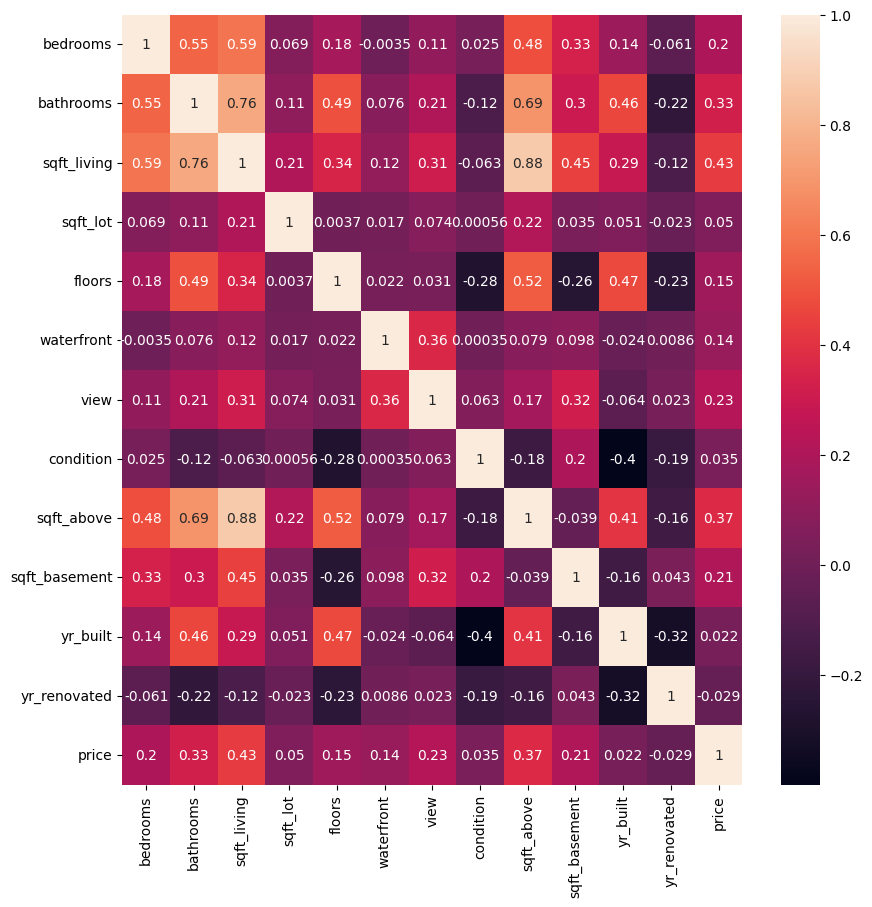

In [19]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset.corr(), annot=True)
plt.show()

In [22]:
x = dataset.iloc[:,:-1]
y= dataset["price"]

In [25]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.42)

# ***import mean squred error and mean absolute error***

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ***Linear Regression***

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)*100

47.21848361190525

make graph for better understanding

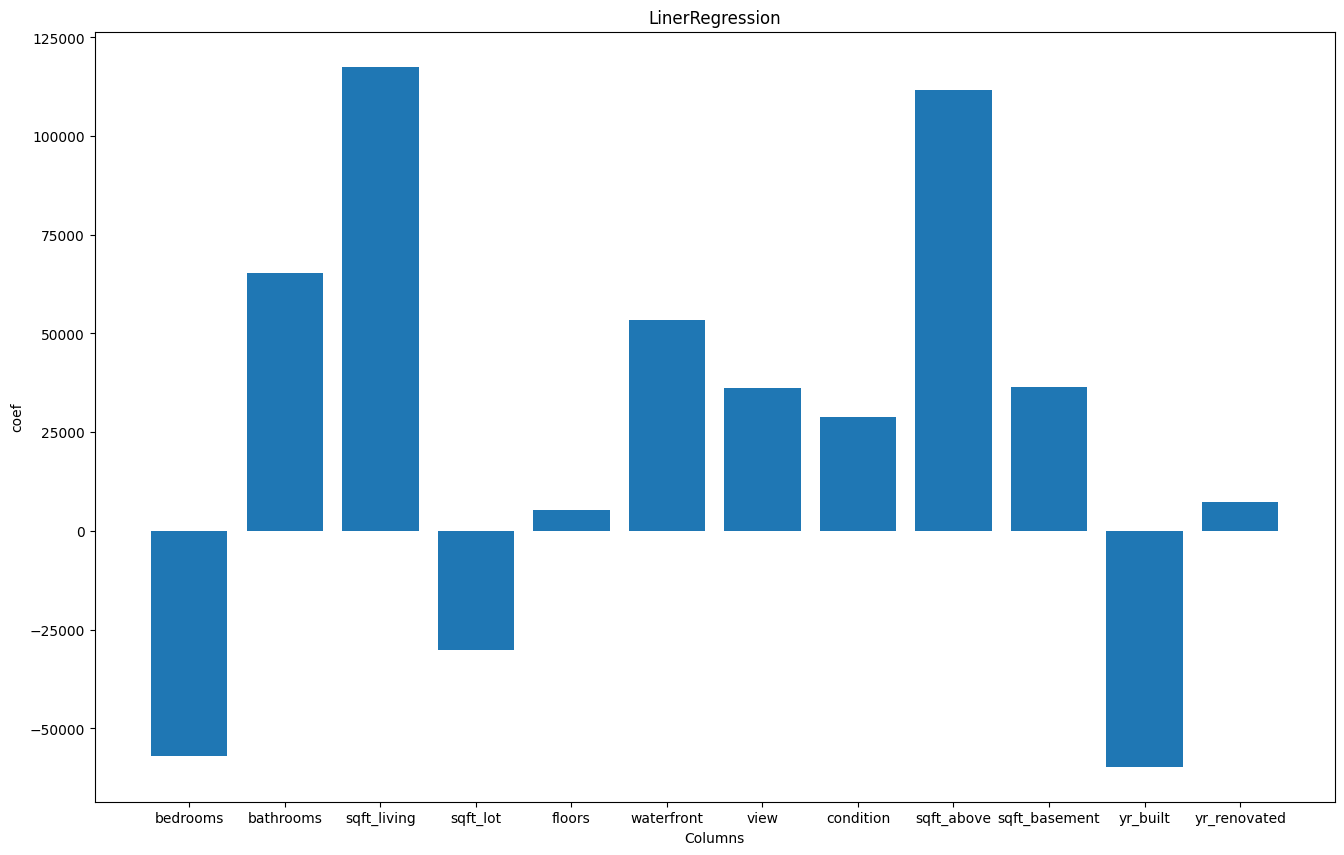

In [46]:
plt.figure(figsize=(16,10))
plt.bar(x.columns,lr.coef_)
plt.title("LinerRegression")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

***Mean Squraed error***

In [62]:
print(mean_squared_error(y_test,lr.predict(x_test)))

69802640135.4015


***Mean absolute error***

In [63]:
print(mean_absolute_error(y_test,lr.predict(x_test)))

163910.84995907077


***Root Mean squraed error***

In [66]:
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

264201.8927551457


# **Lasso**

In [48]:
from sklearn.linear_model import Lasso

In [52]:
la = Lasso(alpha=0.01)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.439e+12, tolerance: 1.206e+11
  model = cd_fast.enet_coordinate_descent(


47.218485533360735

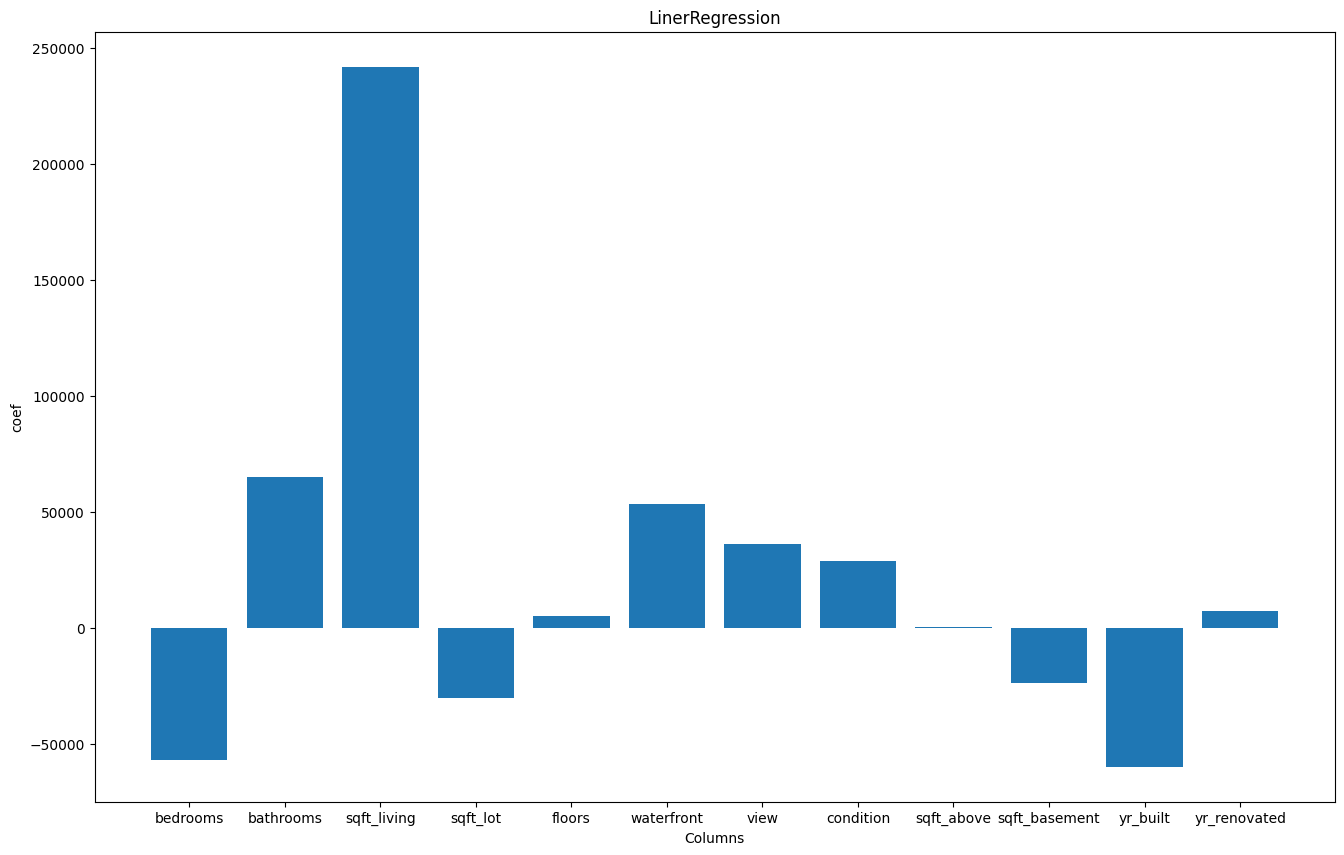

In [54]:
plt.figure(figsize=(16,10))
plt.bar(x.columns,la.coef_)
plt.title("LinerRegression")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

***find MSE & MAE & RSE***

In [69]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))


69802637594.30995
163910.8462400041
264201.8879461499


# ***Ridge***

In [55]:
from sklearn.linear_model import Ridge

In [58]:
ri = Ridge(alpha=10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

47.23947474777872

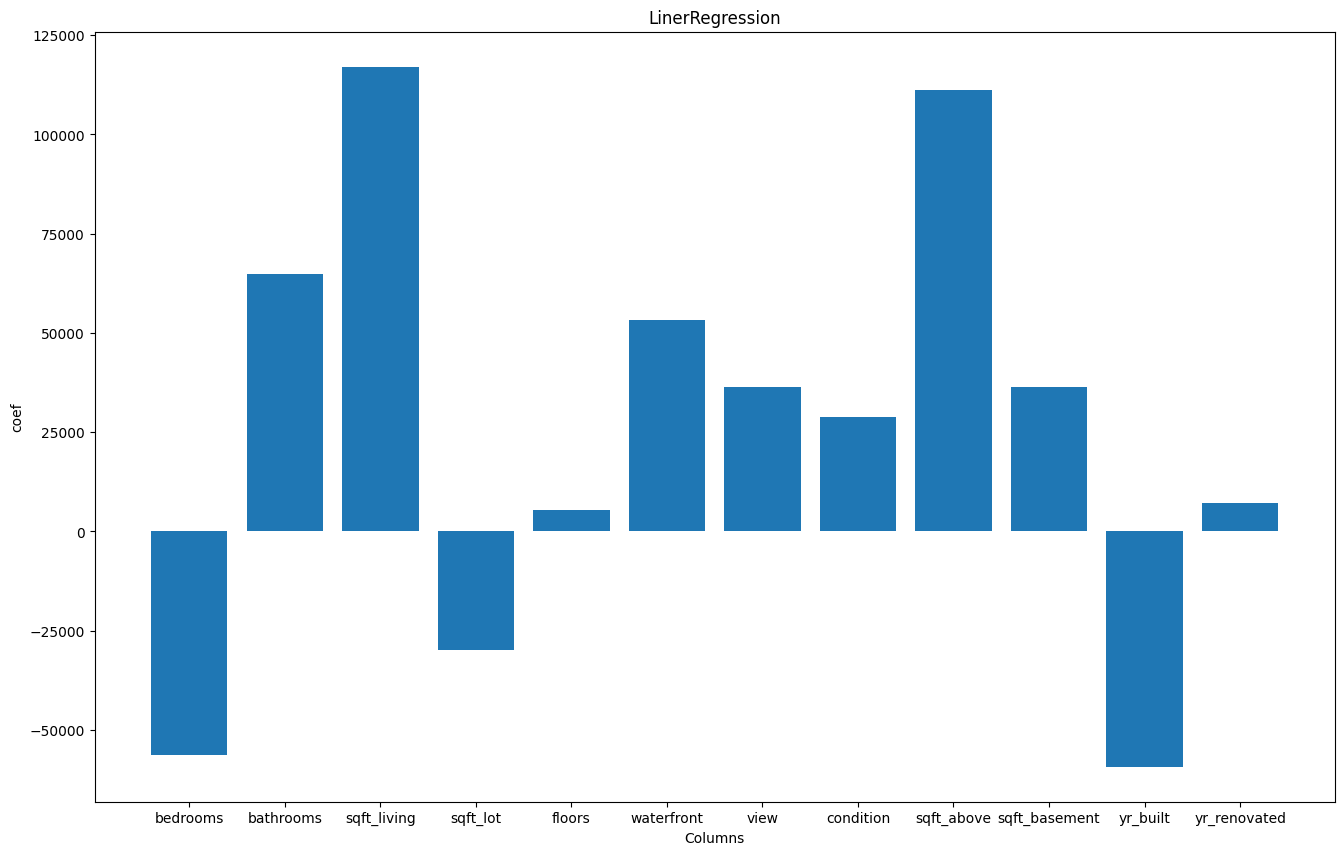

In [59]:
plt.figure(figsize=(16,10))
plt.bar(x.columns,ri.coef_)
plt.title("LinerRegression")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

***find MSE & MAE & RSE***

In [70]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))


69774879722.21756
163815.23173566084
264149.35116751195


compare LinearRegression , Lasso and Ridge

In [74]:
df = pd.DataFrame({"col_name":x.columns,"LinearRegression":lr.coef_,"Lasso":la.coef_,"Ridge":ri.coef_})
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,-56991.658240,-56991.633558,-56178.665968
1,bathrooms,65223.899072,65223.863306,64903.958054
2,sqft_living,117579.451729,241969.076475,117081.192140
3,sqft_lot,-30163.785322,-30163.769837,-29855.169090
4,floors,5288.677174,5288.677206,5519.246191
5,waterfront,53425.195439,53425.185679,53219.331822
6,view,36200.171725,36200.168075,36373.996206
7,condition,28774.587804,28774.570942,28730.925177
8,sqft_above,111752.139877,410.656317,111196.952382
9,sqft_basement,36420.506530,-23518.677126,36417.788266
